# CDPHE Air Toxics Data Access Quickstart

This notebook demonstrates how to query the public S3 data lake using **DuckDB**.

### Prerequisites

Before running this notebook, ensure you have the required libraries installed. You can install them using the `requirements.txt` file in the root of this repository:

```bash
pip install -r requirements.txt
conda create --name atmd-data-tools --file requirements.txt
```


Welcome to the public data lake. Our data is stored in a highly optimized Parquet format on Amazon S3.

Before we query the massive raw datasets, let's look at our **Data Catalog** to see exactly what datasets are available, their date ranges, and their specific `dataset_id`.


In [1]:
import contextily as cx
import duckdb
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Connect to a local, in-memory DuckDB instance
con = duckdb.connect()

# 2. Install and load the httpfs extension to read directly from web/S3
con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

# 3. Query the catalog.csv directly from S3
catalog_query = """
    SELECT * FROM read_csv_auto('s3://cdphe-atmd-datalake-public/catalog.csv')
"""

# 4. Execute the query and render as a Pandas DataFrame for a clean visual output
catalog_df = con.execute(catalog_query).df()

# Display the catalog
catalog_df

,dataset_id,asset,deployment,file_parts,s3_prefix
0,1,CAT,2023-04-20,data_0.parquet,asset=CAT/deployment=2023-04-20/
1,2,CAT,2023-04-21,data_0.parquet,asset=CAT/deployment=2023-04-21/
2,3,CAT,2024-06-05,data_0.parquet,asset=CAT/deployment=2024-06-05/
3,4,CAT,2024-12-18,data_0.parquet,asset=CAT/deployment=2024-12-18/
4,5,MARMOT-Millie,2023-04-20,data_0.parquet,asset=MARMOT-Millie/deployment=2023-04-20/
5,6,MARMOT-Millie,2023-04-21,data_0.parquet,asset=MARMOT-Millie/deployment=2023-04-21/
6,7,MARMOT-Millie,2024-06-05,data_0.parquet,asset=MARMOT-Millie/deployment=2024-06-05/
7,8,MARMOT-Millie,2025-01-08,data_0.parquet,asset=MARMOT-Millie/deployment=2025-01-08/
8,9,MARMOT-Millie,2025-01-14,data_0.parquet,asset=MARMOT-Millie/deployment=2025-01-14/
9,10,MARMOT-Millie,2025-01-20,data_0.parquet,asset=MARMOT-Millie/deployment=2025-01-20/


## Step 2: Querying Specific Deployment Data

Now that we have identified our target (`asset=CAT` for `2024-12-18`), we can query the data lake.

Because we are using **Hive Partitioning**, DuckDB will only request the data within that specific folder, making the query fast and cost-effective.


In [3]:
# 1. Setup Anonymous S3 Access (public bucket)
con.execute("SET s3_region='us-east-1';")
con.execute("SET s3_access_key_id='';")
con.execute("SET s3_secret_access_key='';")

# 2. Define our target path
# We use the wildcard /*.parquet to ensure we catch all file parts in that folder
target_s3_path = (
    "s3://cdphe-atmd-datalake-public/asset=CAT/deployment=2024-12-18/*.parquet"
)

print(f"Streaming data from: {target_s3_path}...")

# 3. The Query
# Note: hive_partitioning=true allows us to see 'asset' and 'deployment' as columns
query = f"""
    SELECT
        * FROM read_parquet('{target_s3_path}', hive_partitioning=true)
    ORDER BY datetime ASC
"""

# 4. Load and display
deployment_df = con.execute(query).df()

print(f"Successfully loaded {len(deployment_df)} rows.")
deployment_df.head()

Streaming data from: s3://cdphe-atmd-datalake-public/asset=CAT/deployment=2024-12-18/*.parquet...
Successfully loaded 206736 rows.


,atmd_id,device_id,datetime,lat,lon,well_known_text,duration,parameter_name,parameter_value,unit_name,...,qualifier_codes,site,atmd_flags,atmd_is_valid,deployment_id,program,date_loaded,version,asset,deployment
0,None,CAT,2024-12-18 16:08:22,39.78736,-105.11073,POINT (-105.11073 39.78736),2.0,Elevation,1633.6,m,...,QG,Suncor,None,<NA>,6b4745e7-11dd-4c3f-bb29-03d200f531e2,MAT,2025-08-25 23:26:10.821553,1756164370,CAT,2024-12-18
1,None,CAT,2024-12-18 16:08:22,39.78736,-105.11073,POINT (-105.11073 39.78736),2.0,Hydrogen cyanide,1.0,ppb,...,MD QG,Suncor,None,<NA>,6b4745e7-11dd-4c3f-bb29-03d200f531e2,MAT,2025-08-25 23:26:10.821553,1756164370,CAT,2024-12-18
2,None,CAT,2024-12-18 16:08:22,39.78736,-105.11073,POINT (-105.11073 39.78736),2.0,Hydrogen sulfide,0.0,ppb,...,MD QG,Suncor,None,<NA>,6b4745e7-11dd-4c3f-bb29-03d200f531e2,MAT,2025-08-25 23:26:10.821553,1756164370,CAT,2024-12-18
3,None,CAT,2024-12-18 16:08:22,39.78736,-105.11073,POINT (-105.11073 39.78736),2.0,Benzene,NaN,ppb,...,MD BD QG,Suncor,None,<NA>,6b4745e7-11dd-4c3f-bb29-03d200f531e2,MAT,2025-08-25 23:26:10.821553,1756164370,CAT,2024-12-18
4,None,CAT,2024-12-18 16:08:22,39.78736,-105.11073,POINT (-105.11073 39.78736),2.0,Toluene,NaN,ppb,...,MD BD QG,Suncor,None,<NA>,6b4745e7-11dd-4c3f-bb29-03d200f531e2,MAT,2025-08-25 23:26:10.821553,1756164370,CAT,2024-12-18


## Step 3: Investigate!


In [4]:
cat_benzene_data = deployment_df.loc[
    deployment_df.parameter_name == "Benzene",
    ["datetime", "parameter_value", "lat", "lon"],
].dropna()
cat_benzene_data["datetime"] = pd.to_datetime(
    cat_benzene_data["datetime"], format="ISO8601", utc=True
)
cat_benzene_data["datetime"] = cat_benzene_data.datetime.dt.tz_convert("America/Denver")
cat_benzene_data

,datetime,parameter_value,lat,lon
1011,2024-12-18 09:11:12-07:00,3.4,39.78659,-105.10784
1023,2024-12-18 09:11:14-07:00,2.9,39.78660,-105.10784
1035,2024-12-18 09:11:16-07:00,3.2,39.78660,-105.10784
1047,2024-12-18 09:11:17-07:00,3.2,39.78660,-105.10784
1059,2024-12-18 09:11:19-07:00,2.9,39.78561,-105.10788
...,...,...,...,...
206678,2024-12-18 14:00:15-07:00,1.3,39.78484,-105.10432
206690,2024-12-18 14:00:17-07:00,1.3,39.78484,-105.10417
206702,2024-12-18 14:00:19-07:00,1.2,39.78483,-105.10402
206714,2024-12-18 14:00:21-07:00,1.5,39.78482,-105.10387


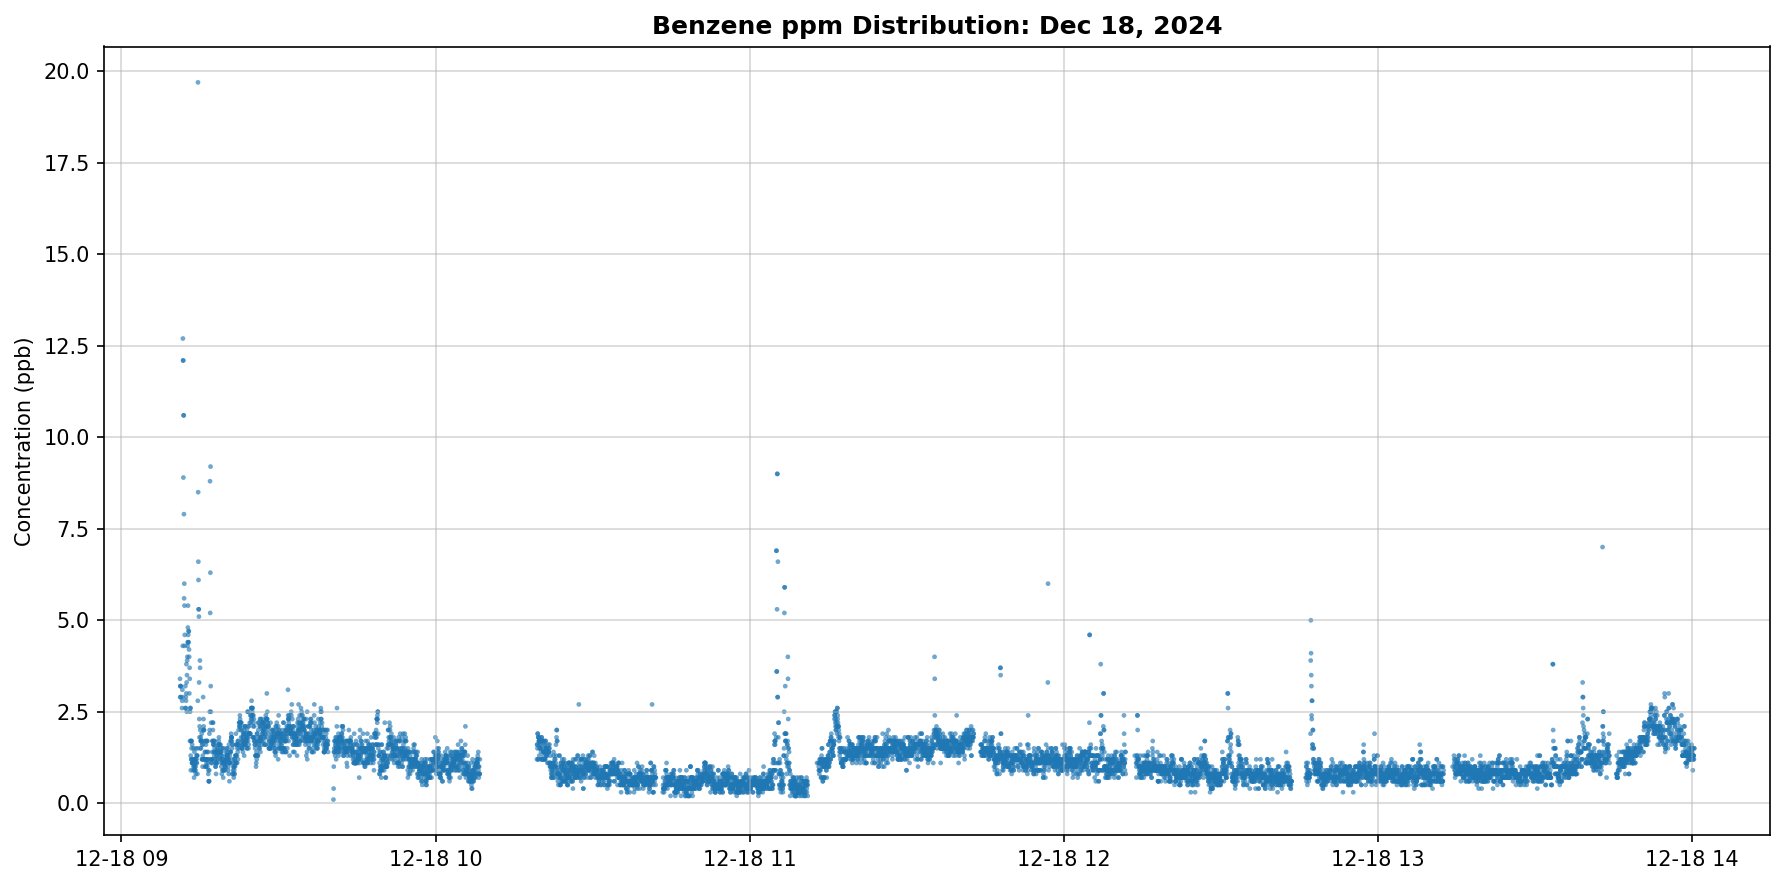

In [5]:
plt.figure(figsize=(12, 6), dpi=150)

plt.scatter(
    cat_benzene_data["datetime"],
    cat_benzene_data["parameter_value"],
    s=5,
    alpha=0.4,
    edgecolor="none",
)

plt.title("Benzene ppm Distribution: Dec 18, 2024", fontweight="bold")
plt.ylabel("Concentration (ppb)")
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

### Use latitude and longitude to plot concentrations over a map


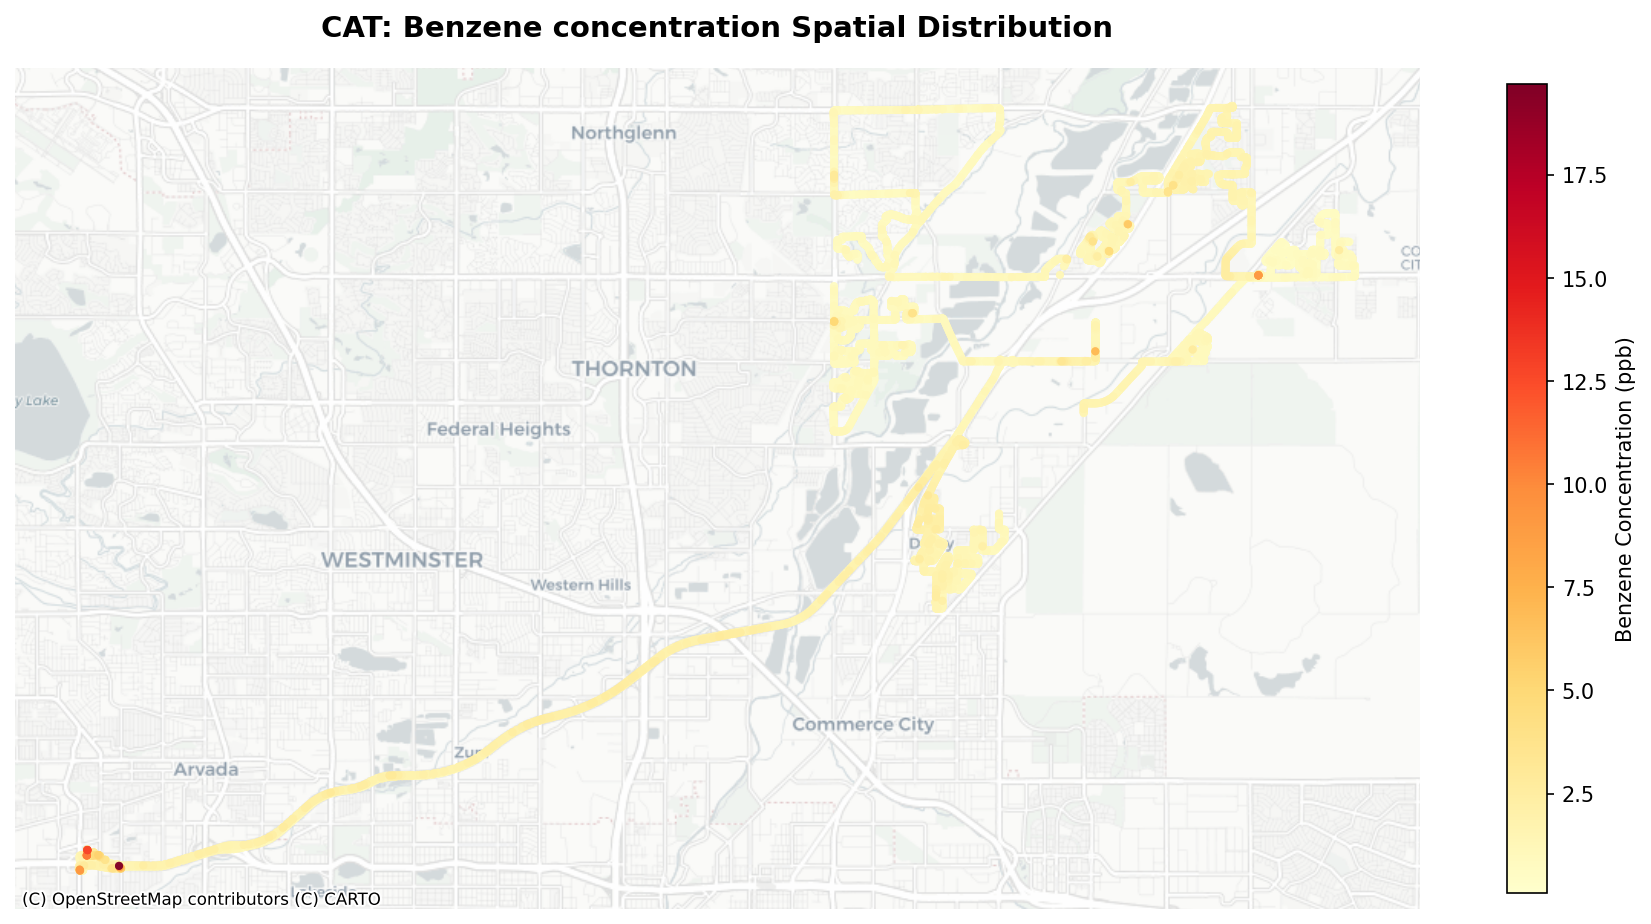

In [ ]:
# 1. Convert the Pandas DataFrame into a GeoDataFrame
# We tell it which columns hold the coordinates and that they are standard GPS (EPSG:4326)
gdf = gpd.GeoDataFrame(
    cat_benzene_data,
    geometry=gpd.points_from_xy(cat_benzene_data.lon, cat_benzene_data.lat),
    crs="EPSG:4326",
)
gdf.sort_values(
    "parameter_value", inplace=True
)  # Sort so that higher benzene points are plotted on top

# 2. Reproject to Web Mercator
gdf_web_mercator = gdf.to_crs(epsg=3857)


# 3. Plot the data
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)
gdf_web_mercator.plot(
    ax=ax,
    column="parameter_value",
    cmap="YlOrRd",
    markersize=15,
    alpha=0.8,
    edgecolor="none",
    legend=True,
    legend_kwds={
        "label": "Benzene Concentration (ppb)",
        "orientation": "vertical",
        "shrink": 0.7,
    },
)

# 4. Add the static basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

# 5. Styling
plt.title(
    "CAT: Benzene concentration Spatial Distribution",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_axis_off()

plt.tight_layout()
plt.show()